In [2]:
#── Imports ───────────────────────────────────────────────────────────────────
import logging
import os
from typing import Annotated, Literal, Sequence

from dotenv import load_dotenv
from pydantic import BaseModel, Field
from typing_extensions import TypedDict
from langchain_community.document_loaders import PyPDFLoader
from langchain.chat_models import init_chat_model
from langchain.tools import tool
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.vectorstores import FAISS
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate, PromptTemplate
from langchain_openai import OpenAIEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import END, START, StateGraph
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition
from typing import List
### load llm models
import os
from langchain.chat_models import init_chat_model
from dotenv import load_dotenv
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
llm=init_chat_model("openai:gpt-4o")

In [7]:
import os
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS

# --- CHECKPOINT 1: File Discovery ---
pdf_paths = [
    "./pdf/Earnings-Presentation-Q3-2025-Final.pdf",
    "./pdf/ICIBM 2025_submission_43_paper_v2.pdf",
]

docs = []
for path in pdf_paths:
    if os.path.exists(path):
        loader = PyPDFLoader(path)
        data = loader.load()
        print(f"✅ Loaded {len(data)} pages from {path}")
        docs.extend(data)
    else:
        print(f"❌ File NOT found: {os.path.abspath(path)}")

# --- CHECKPOINT 2: Data Validation ---
if not docs:
    raise ValueError("No documents were loaded. Check your file paths or PDF content!")

# Ensure we aren't accidentally overwriting 'docs' here with a WebBaseLoader!

# --- CHECKPOINT 3: Splitting ---
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=100,
)
doc_splits = text_splitter.split_documents(docs)
print(f"✂️ Created {len(doc_splits)} text chunks.")

if not doc_splits:
    raise ValueError("Documents were loaded, but splitting resulted in 0 chunks. Are the PDFs empty or images?")

# --- CHECKPOINT 4: Vector Store ---
embedding = OpenAIEmbeddings(model="text-embedding-3-small")
vectorstore = FAISS.from_documents(documents=doc_splits, embedding=embedding)

print("🚀 Vector store successfully built!")

✅ Loaded 18 pages from ./pdf/Earnings-Presentation-Q3-2025-Final.pdf
✅ Loaded 10 pages from ./pdf/ICIBM 2025_submission_43_paper_v2.pdf
✂️ Created 92 text chunks.
🚀 Vector store successfully built!


In [14]:
retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

In [9]:
from typing import List, Annotated
import operator
from langchain_core.documents import Document
from langchain_core.messages import BaseMessage, HumanMessage

class RAGReflectionState(BaseModel):
    question: str
    # Using Annotated with operator.add allows nodes to append to the list 
    # instead of overwriting it entirely.
    retrieved_docs: Annotated[List[Document], operator.add] = []
    answer: str = ""
    reflection: str = ""
    revised: bool = False
    attempts: int = 0
    next_step: str = "" # Useful for conditional routing

In [11]:
# -------------------------
# 3. Nodes
# -------------------------

# a. Retrieve
def retrieve_docs(state: RAGReflectionState) -> RAGReflectionState:
    docs = retriever.invoke(state.question)
    return state.model_copy(update={"retrieved_docs": docs})

# b. Generate Answer
def generate_answer(state: RAGReflectionState) -> RAGReflectionState:
    
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"""
Use the following context to answer the question:

Context:
{context}

Question:
{state.question}
"""
    answer = llm.invoke(prompt).content.strip()
    return state.model_copy(update={"answer": answer, "attempts": state.attempts + 1})

# c. Self-Reflect
def reflect_on_answer(state: RAGReflectionState) -> RAGReflectionState:
    
    prompt = f"""
Reflect on the following answer to see if it fully addresses the question. 
State YES if it is complete and correct, or NO with an explanation.

Question: {state.question}

Answer: {state.answer}

Respond like:
Reflection: YES or NO
Explanation: ...
"""
    result = llm.invoke(prompt).content
    is_ok = "reflection: yes" in result.lower()
    return state.model_copy(update={"reflection": result, "revised": not is_ok})

# d. Finalizer
def finalize(state: RAGReflectionState) -> RAGReflectionState:
    return state

In [ ]:
# -------------------------
# 4. LangGraph DAG
# -------------------------
builder = StateGraph(RAGReflectionState)

builder.add_node("retriever", retrieve_docs)
builder.add_node("responder", generate_answer)
builder.add_node("reflector", reflect_on_answer)
builder.add_node("done", finalize)

builder.set_entry_point("retriever")

builder.add_edge("retriever", "responder")
builder.add_edge("responder", "reflector")
builder.add_conditional_edges(
    "reflector",
    lambda s: "done" if not s.revised or s.attempts >= 2 else "retriever"
)

builder.add_edge("done", END)
graph = builder.compile()

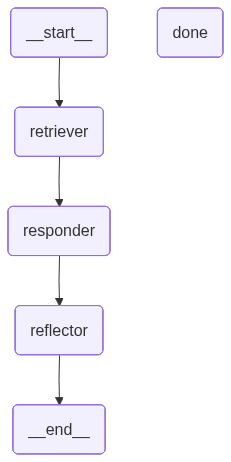

In [16]:
graph

In [15]:
# -------------------------
# 5. Run the Agent
# -------------------------
if __name__ == "__main__":
    user_query = "What is the meta q3 earnings?"
    init_state = RAGReflectionState(question=user_query)
    result = graph.invoke(init_state)

    print("\n🧠 Final Answer:\n", result["answer"])
    print("\n🔁 Reflection Log:\n", result["reflection"])
    print("🔄 Total Attempts:", result["attempts"])


🧠 Final Answer:
 For Q3 2025, Meta reported a diluted earnings per share (EPS) of $1.05 and a net income of $2.71 billion. However, these figures included a one-time, non-cash income tax charge of $15.93 billion related to the implementation of the One Big Beautiful Bill Act. Excluding this charge, the diluted EPS would have increased by $6.20 to $7.25, and the net income would have been $18.64 billion.

🔁 Reflection Log:
 Reflection: NO  
Explanation: The answer provides specific figures for Meta's Q3 2025 earnings, including EPS and net income, as well as an explanation of an extraordinary charge affecting these numbers. However, the question does not specify which year the Q3 earnings are being requested for, and the answer assumes Q3 2025. Without the specific year in the question, it's not possible to determine if the answer fully addresses the question. Additionally, the answer should clarify the impact on revenue, operational performance, or any broader financial highlights to 